   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 60.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 100.6 MB/s eta 0:00:00


Saving food detect.v12-adding-validation-images.yolov8.zip to food detect.v12-adding-validation-images.yolov8.zip
Dataset ready at: food detect.v12-adding-validation-images.yolov8
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=food detect.v12-adding-validation-images.yolov8/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=F

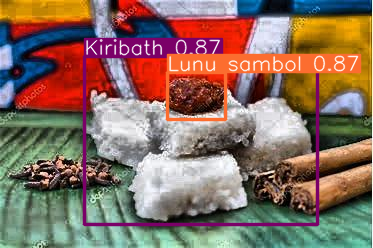

In [1]:
# Step 0: Install packages
!pip install ultralytics roboflow --quiet

# Step 1: Upload your dataset ZIP
from google.colab import files
uploaded = files.upload()  # choose your ZIP file

# Step 2: Unzip the dataset
import zipfile
import os
for fn in uploaded.keys():
    with zipfile.ZipFile(fn, 'r') as zip_ref:
        zip_ref.extractall(fn.replace(".zip",""))

dataset_path = fn.replace(".zip","")
print("Dataset ready at:", dataset_path)

# Step 3: Train a small YOLOv8 model quickly
from ultralytics import YOLO

# Use yolov8n.pt (nano) for very fast training
model = YOLO("yolov8s.pt")

# Quick training settings for testing
model.train(
    data=f"{dataset_path}/data.yaml",  # path to data.yaml
    epochs=40,                          # small number of epochs for fast start
    imgsz=640,                         # smaller images to speed up
    batch=4,                            # smaller batch for Colab free
    project="meal_plate_test",          # save results here
    name="quick_train",
    exist_ok=True,
    device=0
)

# Step 4: Test on one example image
example_image = os.path.join(dataset_path, "valid/images", os.listdir(os.path.join(dataset_path, "valid/images"))[0])
results = model.predict(example_image)
results[0].show()  # show the first (and only) result



Testing on: ok29_PNG.rf.0b420a2a80f680dff061b519f6277d10.jpg

image 1/1 /content/food detect.v12-adding-validation-images.yolov8/valid/images/ok29_PNG.rf.0b420a2a80f680dff061b519f6277d10.jpg: 608x640 1 Okra curry, 20.3ms
Speed: 5.7ms preprocess, 20.3ms inference, 1.6ms postprocess per image at shape (1, 3, 608, 640)


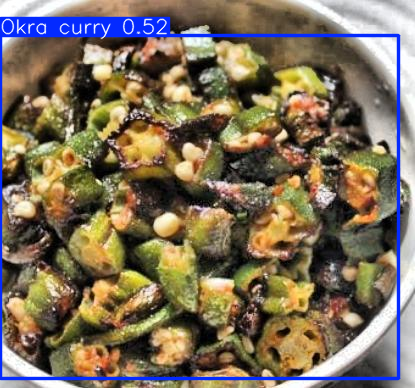

In [6]:
import random
import os

# Pick a random image from your validation set
valid_images_dir = os.path.join(dataset_path, "valid/images")
random_image = random.choice(os.listdir(valid_images_dir))
example_image = os.path.join(valid_images_dir, random_image)

print("Testing on:", random_image)
results = model.predict(example_image)
results[0].show()


Upload new meal plate images (you can select multiple):


Saving cake1.PNG to cake1.PNG
Saving Capture.PNG to Capture.PNG
Saving egg test2.PNG to egg test2.PNG
Saving egg.PNG to egg.PNG
Saving egg3.jpg to egg3.jpg
Saving fied ric etest2.PNG to fied ric etest2.PNG
Saving papdam test2.PNG to papdam test2.PNG
Saving polos test2.jpg to polos test2.jpg
Saving polos test2.PNG to polos test2.PNG
Saving roti tets.jpg to roti tets.jpg
Saving Sausage-Bun-1.jpg to Sausage-Bun-1.jpg
Saving spra test.jpeg to spra test.jpeg
Saving Untitleddesign_13.webp to Untitleddesign_13.webp
13 image(s) uploaded for testing.

--- Testing: new_food_images/cake1.PNG ---

image 1/1 /content/new_food_images/cake1.PNG: 640x512 1 Sweets, 76.2ms
Speed: 3.6ms preprocess, 76.2ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 512)

image 1/1 /content/new_food_images/cake1.PNG: 640x512 1 Sweets, 12.2ms
Speed: 2.5ms preprocess, 12.2ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 512)


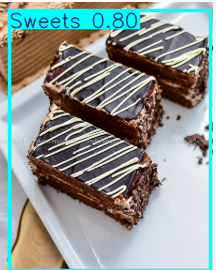

Detected foods:
  - Sweets, Confidence: 0.80

--- Testing: new_food_images/Capture.PNG ---

image 1/1 /content/new_food_images/Capture.PNG: 608x640 1 Sweets, 75.6ms
Speed: 3.6ms preprocess, 75.6ms inference, 1.8ms postprocess per image at shape (1, 3, 608, 640)

image 1/1 /content/new_food_images/Capture.PNG: 608x640 1 Sweets, 16.1ms
Speed: 5.5ms preprocess, 16.1ms inference, 2.2ms postprocess per image at shape (1, 3, 608, 640)


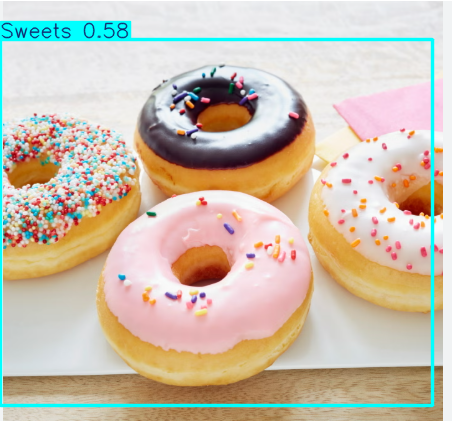

Detected foods:
  - Sweets, Confidence: 0.58

--- Testing: new_food_images/egg test2.PNG ---

image 1/1 /content/new_food_images/egg test2.PNG: 480x640 (no detections), 87.2ms
Speed: 5.2ms preprocess, 87.2ms inference, 0.9ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /content/new_food_images/egg test2.PNG: 480x640 (no detections), 13.0ms
Speed: 3.3ms preprocess, 13.0ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)


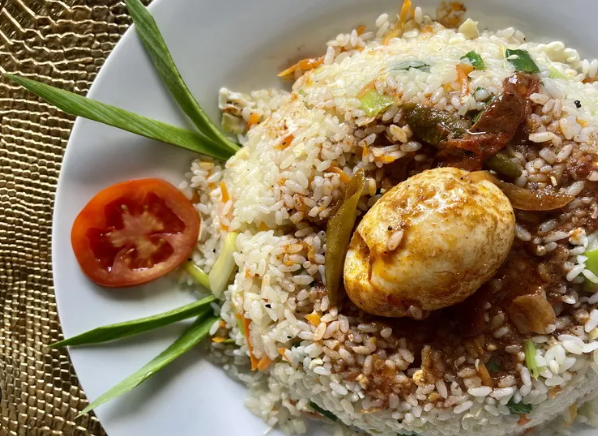

Detected foods:

--- Testing: new_food_images/egg.PNG ---

image 1/1 /content/new_food_images/egg.PNG: 640x608 1 Egg curry, 73.9ms
Speed: 3.8ms preprocess, 73.9ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 608)

image 1/1 /content/new_food_images/egg.PNG: 640x608 1 Egg curry, 16.1ms
Speed: 3.2ms preprocess, 16.1ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 608)


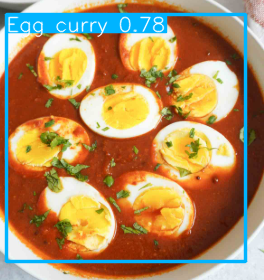

Detected foods:
  - Egg curry, Confidence: 0.78

--- Testing: new_food_images/egg3.jpg ---

image 1/1 /content/new_food_images/egg3.jpg: 576x640 1 Sausage Hotdog, 1 rice, 76.5ms
Speed: 3.8ms preprocess, 76.5ms inference, 1.9ms postprocess per image at shape (1, 3, 576, 640)

image 1/1 /content/new_food_images/egg3.jpg: 576x640 1 Sausage Hotdog, 1 rice, 15.9ms
Speed: 4.5ms preprocess, 15.9ms inference, 1.9ms postprocess per image at shape (1, 3, 576, 640)


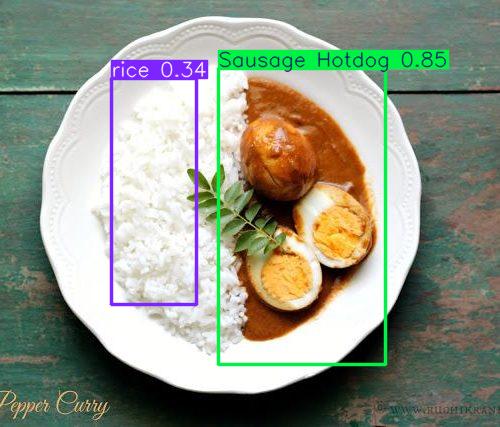

Detected foods:
  - Sausage Hotdog, Confidence: 0.85
  - rice, Confidence: 0.34

--- Testing: new_food_images/fied ric etest2.PNG ---

image 1/1 /content/new_food_images/fied ric etest2.PNG: 448x640 1 Fried rice, 14.1ms
Speed: 4.0ms preprocess, 14.1ms inference, 1.7ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /content/new_food_images/fied ric etest2.PNG: 448x640 1 Fried rice, 12.8ms
Speed: 3.0ms preprocess, 12.8ms inference, 1.6ms postprocess per image at shape (1, 3, 448, 640)


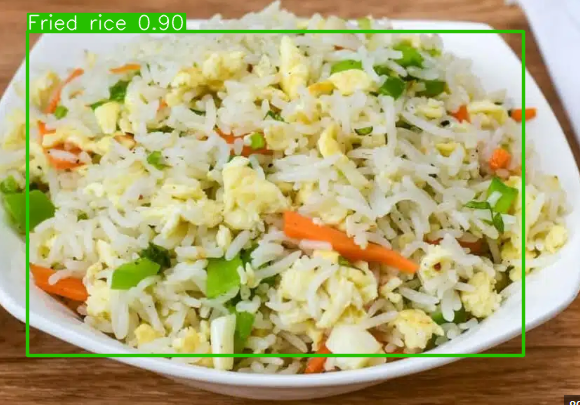

Detected foods:
  - Fried rice, Confidence: 0.90

--- Testing: new_food_images/papdam test2.PNG ---

image 1/1 /content/new_food_images/papdam test2.PNG: 640x640 (no detections), 17.5ms
Speed: 3.5ms preprocess, 17.5ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/new_food_images/papdam test2.PNG: 640x640 (no detections), 16.4ms
Speed: 3.3ms preprocess, 16.4ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)


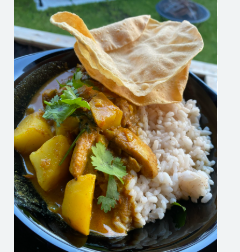

Detected foods:

--- Testing: new_food_images/polos test2.jpg ---

image 1/1 /content/new_food_images/polos test2.jpg: 384x640 1 Gotukola Mallum, 75.2ms
Speed: 3.3ms preprocess, 75.2ms inference, 1.9ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/new_food_images/polos test2.jpg: 384x640 1 Gotukola Mallum, 10.7ms
Speed: 2.9ms preprocess, 10.7ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 640)


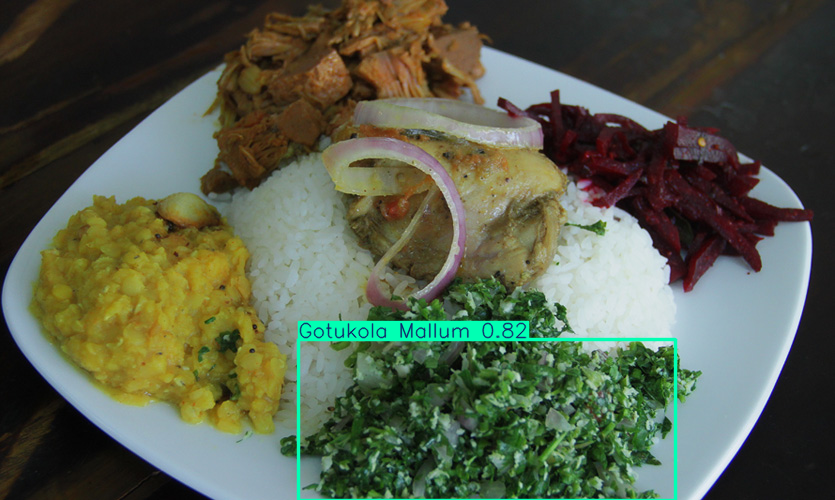

Detected foods:
  - Gotukola Mallum, Confidence: 0.82

--- Testing: new_food_images/polos test2.PNG ---

image 1/1 /content/new_food_images/polos test2.PNG: 544x640 1 Polos curry, 17.6ms
Speed: 3.8ms preprocess, 17.6ms inference, 2.4ms postprocess per image at shape (1, 3, 544, 640)

image 1/1 /content/new_food_images/polos test2.PNG: 544x640 1 Polos curry, 16.9ms
Speed: 3.6ms preprocess, 16.9ms inference, 3.3ms postprocess per image at shape (1, 3, 544, 640)


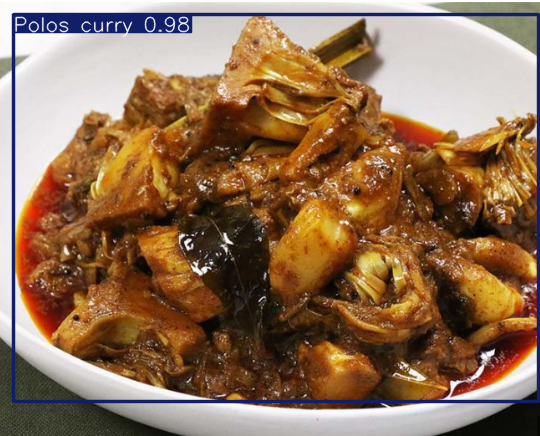

Detected foods:
  - Polos curry, Confidence: 0.98

--- Testing: new_food_images/roti tets.jpg ---

image 1/1 /content/new_food_images/roti tets.jpg: 640x512 1 Cocount roti, 13.5ms
Speed: 3.3ms preprocess, 13.5ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 512)

image 1/1 /content/new_food_images/roti tets.jpg: 640x512 1 Cocount roti, 13.3ms
Speed: 4.4ms preprocess, 13.3ms inference, 3.9ms postprocess per image at shape (1, 3, 640, 512)


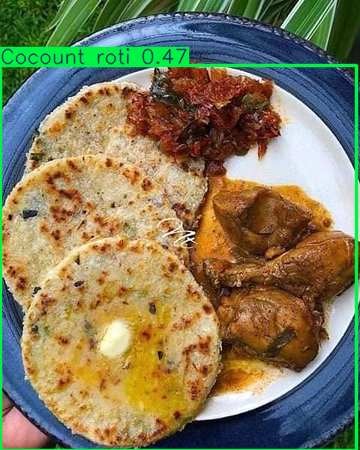

Detected foods:
  - Cocount roti, Confidence: 0.47

--- Testing: new_food_images/Sausage-Bun-1.jpg ---

image 1/1 /content/new_food_images/Sausage-Bun-1.jpg: 384x640 1 Sausage Hotdog, 14.2ms
Speed: 4.9ms preprocess, 14.2ms inference, 2.6ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/new_food_images/Sausage-Bun-1.jpg: 384x640 1 Sausage Hotdog, 13.2ms
Speed: 2.7ms preprocess, 13.2ms inference, 1.9ms postprocess per image at shape (1, 3, 384, 640)


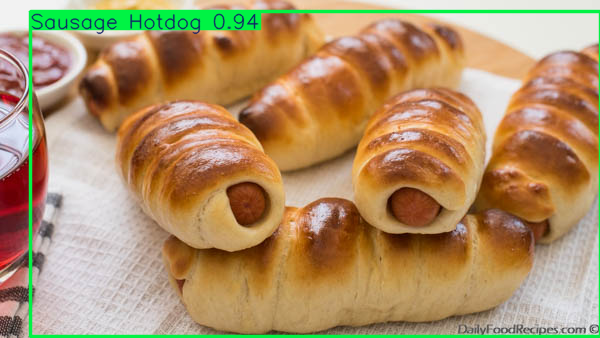

Detected foods:
  - Sausage Hotdog, Confidence: 0.94

--- Testing: new_food_images/spra test.jpeg ---

image 1/1 /content/new_food_images/spra test.jpeg: 448x640 1 Sprats, 14.5ms
Speed: 3.2ms preprocess, 14.5ms inference, 3.5ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /content/new_food_images/spra test.jpeg: 448x640 1 Sprats, 16.4ms
Speed: 2.9ms preprocess, 16.4ms inference, 2.1ms postprocess per image at shape (1, 3, 448, 640)


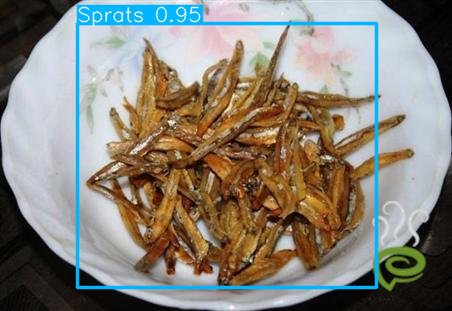

Detected foods:
  - Sprats, Confidence: 0.95

--- Testing: new_food_images/Untitleddesign_13.webp ---

image 1/1 /content/new_food_images/Untitleddesign_13.webp: 640x640 1 Baked Filled, 17.9ms
Speed: 5.5ms preprocess, 17.9ms inference, 2.8ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/new_food_images/Untitleddesign_13.webp: 640x640 1 Baked Filled, 17.1ms
Speed: 5.3ms preprocess, 17.1ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)


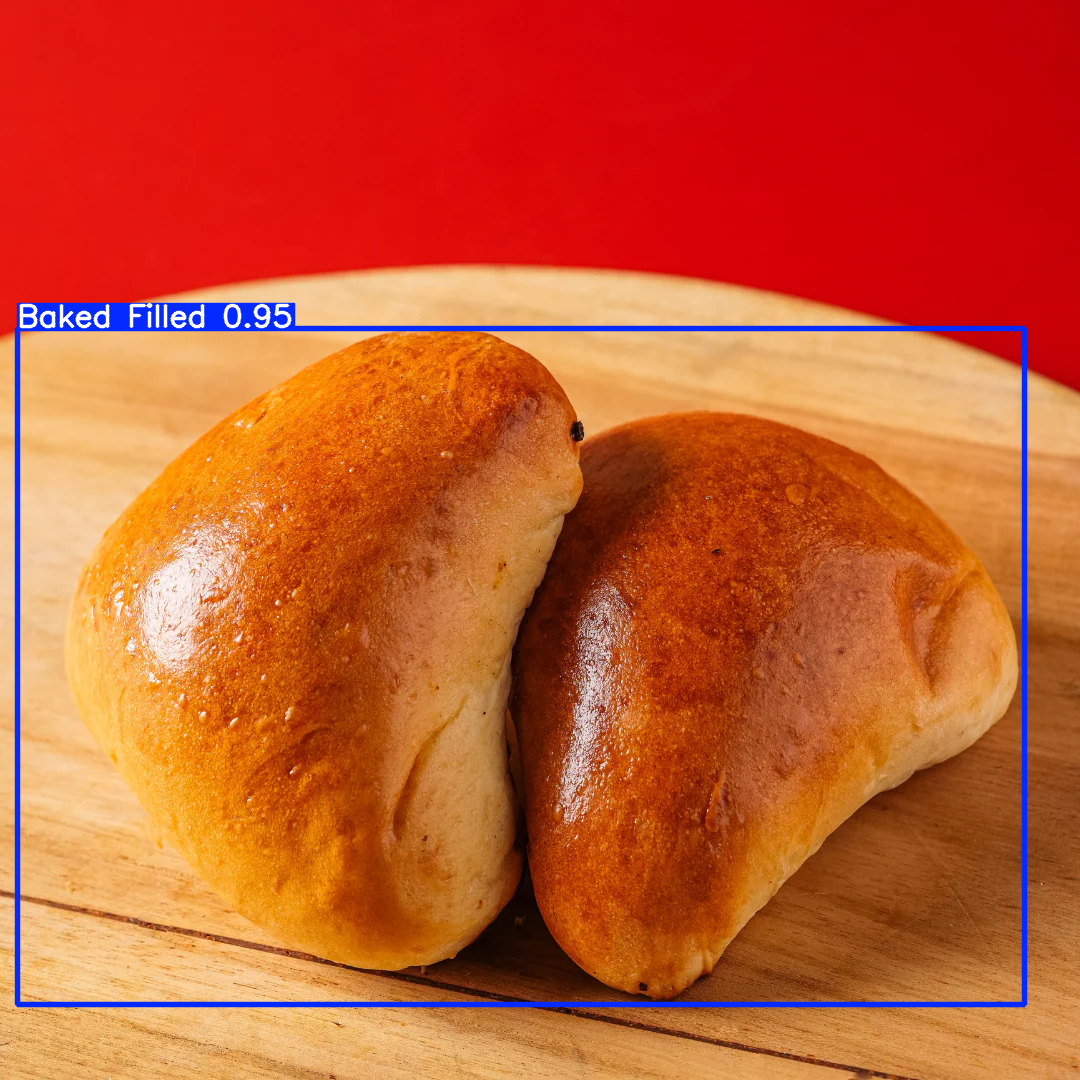

Detected foods:
  - Baked Filled, Confidence: 0.95


In [3]:
# ==========================
# Cell 3: Test on new/unseen images
# ==========================

from ultralytics import YOLO
from google.colab import files
import os

# 1️⃣ Load your trained YOLOv8 model
model = YOLO("/content/runs/detect/meal_plate_test/quick_train/weights/best.pt")

# 2️⃣ Upload one or more new images (simulate user uploads)
print("Upload new meal plate images (you can select multiple):")
uploaded = files.upload()  # user selects image files

# 3️⃣ Create a folder to save uploaded images
os.makedirs("new_food_images", exist_ok=True)

# Save uploaded images
uploaded_files = []
for filename in uploaded.keys():
    path = os.path.join("new_food_images", filename)
    uploaded_files.append(path)
    with open(path, "wb") as f:
        f.write(uploaded[filename])
print(f"{len(uploaded_files)} image(s) uploaded for testing.")

# 4️⃣ Run predictions on each uploaded image
for img_path in uploaded_files:
    print("\n--- Testing:", img_path, "---")
    results = model.predict(img_path)  # Run YOLO detection

    # Show the image with bounding boxes
    results = model.predict(img_path)  # Run YOLO detection

    # Show the image with bounding boxes
    results[0].show()

    # Print detected foods with confidence scores
    print("Detected foods:")
    for box in results[0].boxes:
        class_id = int(box.cls[0])
        confidence = float(box.conf[0])
        class_name = model.names[class_id]
        print(f"  - {class_name}, Confidence: {confidence:.2f}")
